# 4.2 - Visualizing Text Data

Practice exercise using **yelp_subset.csv**.


## 1. Read in the data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import re
import warnings

from collections import Counter
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob

warnings.filterwarnings("ignore")

df = pd.read_csv('../assets/yelp_subset.csv')
df.head()

,review_id,user_id,business_id,date,text,useful,funny,cool,name,neighborhood,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,categories
0,zsbVXbCsycrTWkVlsKsVOg,u3NDqJr25UwYeXZypxJcqw,xBkXnzbctPGWG86L27GNFQ,2015-01-03,We brought our Doxie to Dr. Scholten for serio...,0,0,1,"""Hopi Animal Hospital""",NaN,"""5533 E Bell Rd, Ste 101""",Scottsdale,AZ,85254,33.639916,-111.961780,4.5,30,1,Pet Services;Pet Sitting;Pets;Veterinarians
1,d3iCvvJsJZs4U-ZFfq_pSA,DxHP0hTWS9Jpd-xSVCMYAg,JDjOobEd_Tm6Z06YRmWkbg,2008-05-13,"First, I'm a regular here. Sunday afternoons a...",5,3,5,"""Charlie's""",NaN,"""727 W Camelback Rd""",Phoenix,AZ,85013,33.508967,-112.083610,3.0,158,1,Bars;Nightlife;Dance Clubs;Gay Bars
2,yTS2FOyhmRHgwAXSG8muiQ,-aYO8Ga4U5hrwxV7y1IaiA,qiRyyRWt6jmAxcoVW0-WHA,2015-08-02,"Best AYCE in Mississauga. For an AYCE, their s...",6,0,1,"""Heart Sushi""",East Credit,"""815 Britannia Road W, Unit 2""",Mississauga,ON,L5V 2X8,43.610533,-79.698421,3.5,278,1,Chinese;Japanese;Buffets;Restaurants;Sushi Bars
3,W1PG83hPCogZdLlstltWZw,EJLsnsI53YKBHq9te2KSiQ,t67GMPZ0cv_ItKlID-JFiQ,2013-04-10,"Love it! It's a nice quick, inexpensive & tast...",0,1,0,"""Banzo""",NaN,"""2105 Sherman Ave""",Madison,WI,53704,43.101672,-89.364595,4.5,286,1,Food;Mediterranean;Food Trucks;Restaurants
4,Q8IuYiUzeK-Uc8mK-luL3w,gknq0IAq9jaSlotJ465FGw,6P-JmU0VW-qhYq7It1wowg,2014-11-10,Dont eat here! Doesnt even taste like pho here...,0,0,0,"""Pho 68""",NaN,"""2025 N Dobson Rd""",Chandler,AZ,85224,33.336151,-111.874338,3.5,77,0,Vietnamese;Restaurants


In [3]:
df.shape, df.columns.tolist()

((2000, 20),
 ['review_id',
  'user_id',
  'business_id',
  'date',
  'text',
  'useful',
  'funny',
  'cool',
  'name',
  'neighborhood',
  'address',
  'city',
  'state',
  'postal_code',
  'latitude',
  'longitude',
  'stars',
  'review_count',
  'is_open',
  'categories'])

## 2. Word cloud for reviews where **"cleaning"** appears in **categories**

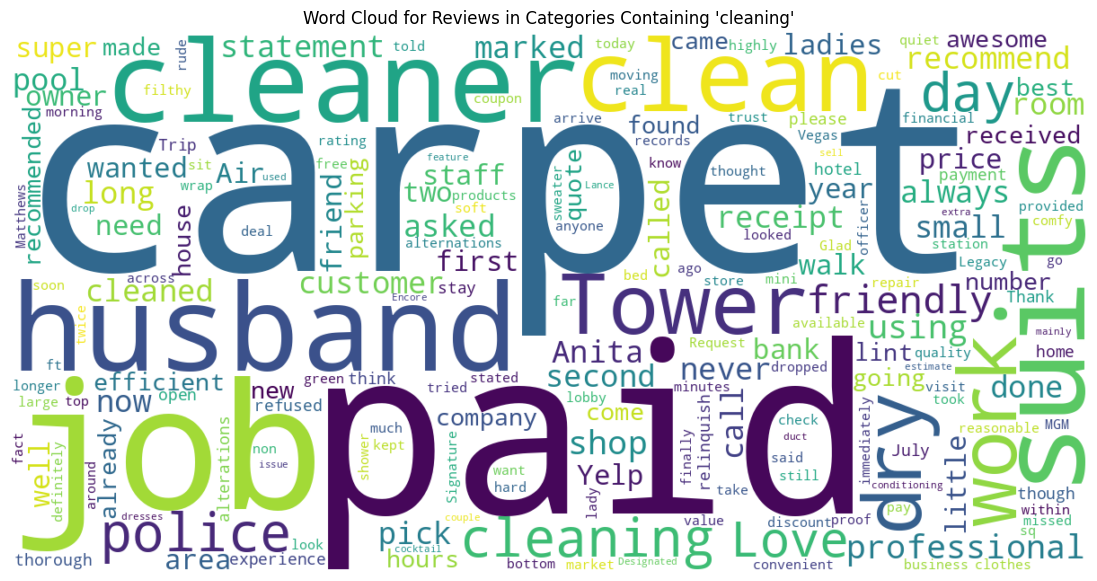

Number of reviews in cleaning-related categories: 23


In [4]:
cleaning_mask = df['categories'].str.contains('cleaning', case=False, na=False)

cleaning_reviews = ' '.join(df.loc[cleaning_mask, 'text'].dropna().astype(str))

custom_stopwords = set(STOPWORDS).union({
    'good', 'great', 'place', 'service', 'services', 'really', 'also',
    'would', 'one', 'get', 'got', 'back', 'time', 'even', 'went', 'like',
    'us', 'can', 'will', 'just'
})

cleaning_wc = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=custom_stopwords,
    collocations=False
).generate(cleaning_reviews)

plt.figure(figsize=(14, 7))
plt.imshow(cleaning_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for Reviews in Categories Containing 'cleaning'")
plt.show()

print("Number of reviews in cleaning-related categories:", cleaning_mask.sum())

## 3. Word cloud for another category

I chose **Auto Repair** as the comparison category.


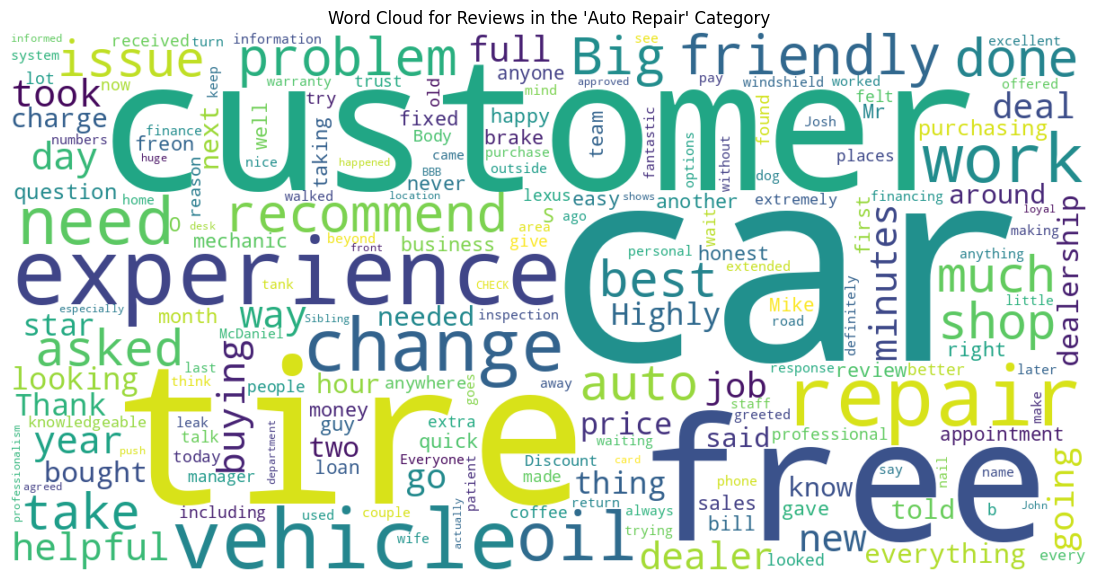

Number of reviews in auto repair category: 42


In [5]:
auto_mask = df['categories'].str.contains('auto repair', case=False, na=False)

auto_reviews = ' '.join(df.loc[auto_mask, 'text'].dropna().astype(str))

auto_wc = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=custom_stopwords,
    collocations=False
).generate(auto_reviews)

plt.figure(figsize=(14, 7))
plt.imshow(auto_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for Reviews in the 'Auto Repair' Category")
plt.show()

print("Number of reviews in auto repair category:", auto_mask.sum())

In [6]:
def get_top_words(text_series, stopwords, n=15):
    all_text = ' '.join(text_series.dropna().astype(str)).lower()
    words = re.findall(r"[a-z']+", all_text)
    words = [w for w in words if len(w) > 2 and w not in stopwords]
    return Counter(words).most_common(n)

cleaning_top = get_top_words(df.loc[cleaning_mask, 'text'], custom_stopwords, 15)
auto_top = get_top_words(df.loc[auto_mask, 'text'], custom_stopwords, 15)

cleaning_top_df = pd.DataFrame(cleaning_top, columns=['word', 'cleaning_freq'])
auto_top_df = pd.DataFrame(auto_top, columns=['word', 'auto_repair_freq'])

comparison = cleaning_top_df.merge(auto_top_df, on='word', how='outer').fillna(0)
comparison.sort_values(['cleaning_freq', 'auto_repair_freq'], ascending=False).head(20)

,word,cleaning_freq,auto_repair_freq
16,paid,11.0,0.0
2,carpet,10.0,0.0
13,job,10.0,0.0
21,suits,10.0,0.0
4,clean,9.0,0.0
12,husband,9.0,0.0
5,cleaning,8.0,0.0
8,dry,8.0,0.0
17,police,8.0,0.0
24,tower,8.0,0.0


### Comparison of the two word clouds

**Words common between both word clouds:**
- **friendly**
- **customer**
- **work**

**Words more specific to cleaning-related businesses:**
- **carpet**
- **suits**
- **dry**
- **clean**
- **cleaner**

**Words more specific to auto repair:**
- **car**
- **repair**
- **oil**
- **tire / tires**
- **vehicle**

Overall, the cleaning-related reviews focus more on the results of the cleaning itself and clothing/carpet-related work, while the auto repair reviews focus more on vehicles, maintenance, and repair services.


## 4. Sentiment of different words in reviews

In [7]:
df['calc_sentiment'] = df['text'].fillna('').apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df['subjectivity'] = df['text'].fillna('').apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)
df['abs_sentiment'] = df['calc_sentiment'].abs()

df[['text', 'calc_sentiment', 'subjectivity']].head()

,text,calc_sentiment,subjectivity
0,We brought our Doxie to Dr. Scholten for serio...,0.267833,0.661333
1,"First, I'm a regular here. Sunday afternoons a...",0.121131,0.426408
2,"Best AYCE in Mississauga. For an AYCE, their s...",0.186667,0.763333
3,"Love it! It's a nice quick, inexpensive & tast...",0.511667,0.640000
4,Dont eat here! Doesnt even taste like pho here...,-0.850000,0.833333


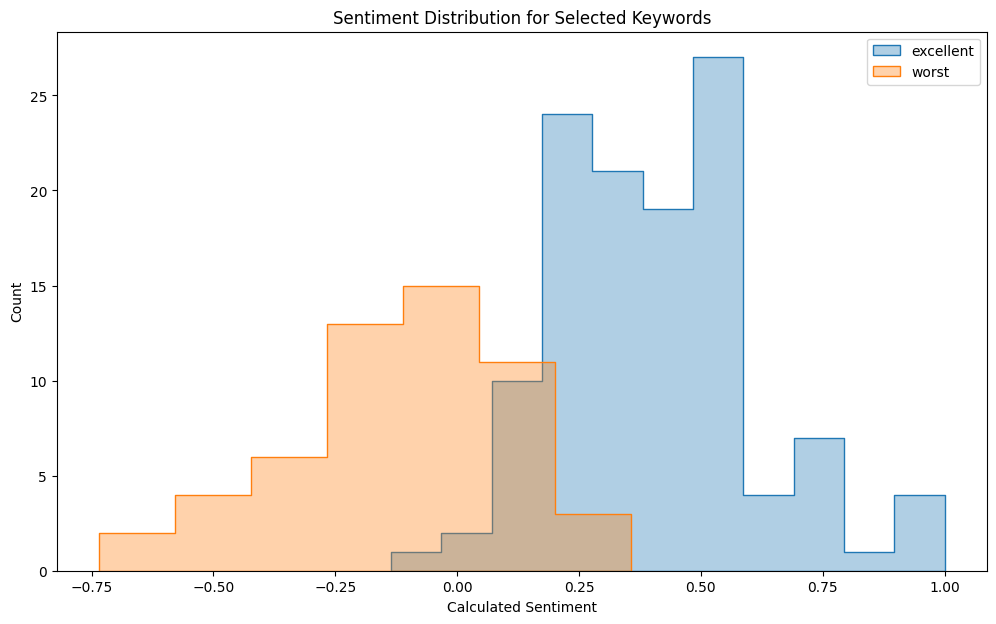

'excellent': count = 120, mean sentiment = 0.406
'worst': count = 54, mean sentiment = -0.110


In [8]:
keywords = ['excellent', 'worst']

sentiments = {}
for keyword in keywords:
    sentiments[keyword] = df[df['text'].str.contains(keyword, case=False, na=False)]['calc_sentiment']

plt.figure(figsize=(12, 7))
for keyword, sentiment in sentiments.items():
    sns.histplot(sentiment, label=keyword, element='step', alpha=0.35)

plt.title('Sentiment Distribution for Selected Keywords')
plt.xlabel('Calculated Sentiment')
plt.ylabel('Count')
plt.legend()
plt.show()

for keyword in keywords:
    keyword_reviews = df['text'].str.contains(keyword, case=False, na=False).sum()
    keyword_mean = df.loc[df['text'].str.contains(keyword, case=False, na=False), 'calc_sentiment'].mean()
    print(f"{keyword!r}: count = {keyword_reviews}, mean sentiment = {keyword_mean:.3f}")

Using these keywords, **excellent** appears to have a very positive sentiment, while **worst** appears to have a very negative sentiment.


## 5. Mean vs. max review length by star rating

In [9]:
df['review_length'] = df['text'].fillna('').str.len()

mean_length = df.groupby('stars', as_index=False)['review_length'].mean()
max_length = df.groupby('stars', as_index=False)['review_length'].max()

mean_length.rename(columns={'review_length': 'mean_review_length'}, inplace=True)
max_length.rename(columns={'review_length': 'max_review_length'}, inplace=True)

length_summary = mean_length.merge(max_length, on='stars')
length_summary

,stars,mean_review_length,max_review_length
0,1.0,630.882353,2591
1,1.5,702.695652,2138
2,2.0,573.673913,2033
3,2.5,785.841667,4223
4,3.0,584.838057,3732
5,3.5,619.423256,3669
6,4.0,612.980551,4010
7,4.5,518.340720,3200
8,5.0,507.474820,3863


In [10]:
fig = px.bar(
    mean_length,
    x='stars',
    y='mean_review_length',
    title='Mean Review Length by Star Rating',
    labels={'stars': 'Star Rating', 'mean_review_length': 'Mean Review Length'}
)
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
fig = px.bar(
    max_length,
    x='stars',
    y='max_review_length',
    title='Max Review Length by Star Rating',
    labels={'stars': 'Star Rating', 'max_review_length': 'Max Review Length'}
)
fig.show()

### Interpretation

The pattern **does change** when using the **max** review length instead of the **mean** review length.

- The **mean review length** is fairly moderate across ratings, with **2.5-star reviews** having the highest average length in this sample.
- The **max review length** is much more uneven because it is driven by a single longest review in each rating group.
- In this dataset, the **2.5-star reviews** have the largest maximum review length, and several mid-to-high ratings also have very long individual reviews.

So, the **mean** gives a better picture of the typical review size, while the **max** highlights extreme cases and makes the pattern look less stable.
